In [1]:
# install dependencies
import subprocess, sys

packages = [
    "datasets",
    "torch",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "transformers",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All dependencies installed.")

All dependencies installed.


In [2]:
# imports
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import re
import time
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import accuracy_score
import pandas as pd
from collections import defaultdict
import torch.nn.functional as F
from tqdm import tqdm

# seeds
RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# data loading
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

dataset = load_dataset("ag_news")

train_full = dataset["train"]
test       = dataset["test"]

split = train_full.train_test_split(test_size=0.10, seed=RANDOM_SEED, shuffle=True)

train = split["train"]
val   = split["test"]

train_texts  = train["text"]
train_labels = train["label"]

val_texts    = val["text"]
val_labels   = val["label"]

test_texts   = test["text"]
test_labels  = test["label"]

print(f"Train size: {len(train)}")
print(f"Val size:   {len(val)}")
print(f"Test size:  {len(test)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 108000
Val size:   12000
Test size:  7600


Vocab size:    34,315
Val OOV rate:  0.0103
Test OOV rate: 0.0102

Sequences truncated: 510/108,000 (0.5%)


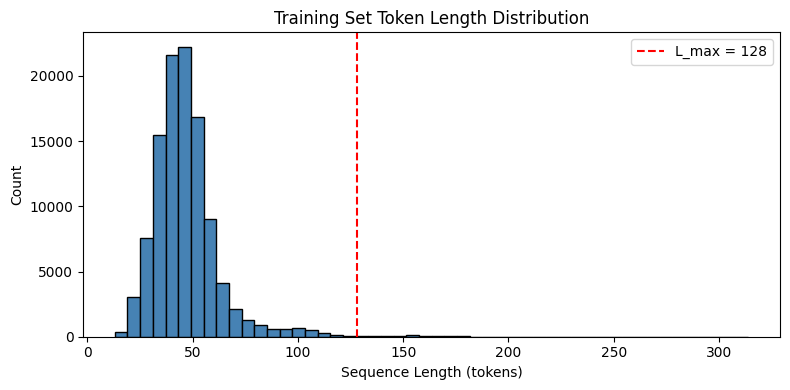


Train label distribution:
  World     : 26,941  (24.9%)
  Sports    : 26,978  (25.0%)
  Business  : 27,019  (25.0%)
  Sci/Tech  : 27,062  (25.1%)

Val label distribution:
  World     :  3,059  (25.5%)
  Sports    :  3,022  (25.2%)
  Business  :  2,981  (24.8%)
  Sci/Tech  :  2,938  (24.5%)

Test label distribution:
  World     :  1,900  (25.0%)
  Sports    :  1,900  (25.0%)
  Business  :  1,900  (25.0%)
  Sci/Tech  :  1,900  (25.0%)

Example text:   American Aphrodite Brooklyn-native Yvette Jarvis is an 'every woman' in Greece: professional basketball player, model, TV and talk show star and Athens councilwoman.
Example tokens: ['american', 'aphrodite', 'brooklyn', '-', 'native', 'yvette', 'jarvis', 'is', 'an', "'", 'every', 'woman', "'", 'in', 'greece', ':', 'professional', 'basketball', 'player', ',']
Example ids:    [2, 4, 1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 12, 15, 16, 17, 18, 19, 20]
Example decode: american brooklyn - native yvette jarvis is an ' every woman ' in greece : prof

In [4]:
# config
class Config:
    def __init__(self):
        self.lowercase        = True
        self.keep_punctuation = True
        self.add_sos          = True
        self.add_eos          = True
        self.min_freq         = 3
        self.max_len          = 128

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.sos_token = "<SOS>"
        self.eos_token = "<EOS>"

config = Config()

# tokenizer
def tokenize(text, config):
    if config.lowercase:
        text = text.lower()
    if config.keep_punctuation:
        return re.findall(r"\w+|[^\w\s]", text)
    else:
        return re.findall(r"\w+", text)

# vocabulary builder
def build_vocab(texts, config):
    word_counts = {}
    for text in texts:
        tokens = tokenize(text, config)
        for token in tokens:
            word_counts[token] = word_counts.get(token, 0) + 1

    vocab   = {config.pad_token: 0, config.unk_token: 1}
    next_id = 2

    if config.add_sos:
        vocab[config.sos_token] = next_id; next_id += 1
    if config.add_eos:
        vocab[config.eos_token] = next_id; next_id += 1

    for word, freq in word_counts.items():
        if freq >= config.min_freq and word not in vocab:
            vocab[word] = next_id
            next_id += 1

    return vocab

# encoder
def encode_text(text, vocab, config):
    tokens = tokenize(text, config)

    if config.add_sos:
        tokens = [config.sos_token] + tokens
    if config.add_eos:
        tokens = tokens + [config.eos_token]

    ids = [vocab.get(t, vocab[config.unk_token]) for t in tokens]
    ids = ids[:config.max_len]

    # if truncated, preserve <EOS> at the last position
    if config.add_eos and len(ids) == config.max_len:
        ids[-1] = vocab[config.eos_token]

    return ids

# decoder
def decode(ids, vocab, config):
    skip       = {vocab[config.pad_token], vocab[config.unk_token],
                  vocab[config.sos_token], vocab[config.eos_token]}
    id_to_word = {v: k for k, v in vocab.items()}
    return " ".join(id_to_word[i] for i in ids if i not in skip)

# build vocab and encode splits
vocab = build_vocab(train_texts, config)

train_encoded = [encode_text(text, vocab, config) for text in train_texts]
val_encoded   = [encode_text(text, vocab, config) for text in val_texts]
test_encoded  = [encode_text(text, vocab, config) for text in test_texts]

# vocab statistics
def oov_rate(encoded_texts, unk_id=1):
    total     = sum(len(seq) for seq in encoded_texts)
    unk_count = sum(seq.count(unk_id) for seq in encoded_texts)
    return unk_count / total

print(f"Vocab size:    {len(vocab):,}")
print(f"Val OOV rate:  {oov_rate(val_encoded):.4f}")
print(f"Test OOV rate: {oov_rate(test_encoded):.4f}")

# sequence length distribution
raw_lengths = [len(tokenize(t, config)) for t in train_texts]
truncated   = sum(1 for l in raw_lengths if l > config.max_len)
print(f"\nSequences truncated: {truncated:,}/{len(raw_lengths):,} "
      f"({100 * truncated / len(raw_lengths):.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(raw_lengths, bins=50, color="steelblue", edgecolor="black")
plt.axvline(config.max_len, color="red", linestyle="--", label=f"L_max = {config.max_len}")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Count")
plt.title("Training Set Token Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150)
plt.show()

# class balance
label_names = ["World", "Sports", "Business", "Sci/Tech"]
print()
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = Counter(labels)
    print(f"{split_name} label distribution:")
    for i, name in enumerate(label_names):
        print(f"  {name:10s}: {counts[i]:6,}  ({100 * counts[i] / len(labels):.1f}%)")
    print()

# sanity check
print("Example text:  ", train_texts[0])
print("Example tokens:", tokenize(train_texts[0], config)[:20])
print("Example ids:   ", train_encoded[0][:20])
print("Example decode:", decode(train_encoded[0], vocab, config))

# example 55 from train_full before shuffling (teammate request)
example_55      = train_full[55]["text"]
tokens_55       = tokenize(example_55, config)
encoded_55      = encode_text(example_55, vocab, config)
label_names_map = ["World", "Sports", "Business", "Sci/Tech"]

print("\nExample 55 (train_full, before shuffling):")
print(f"  Text:   {example_55}")
print(f"  Label:  {label_names_map[train_full[55]['label']]}")
print(f"  Tokens: {tokens_55[:20]}")
print(f"  IDs:    {encoded_55[:20]}")

In [5]:
# seed worker for reproducibility
def seed_worker(worker_id):
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(RANDOM_SEED)

# dataset
class NewsDataset(Dataset):

    def __init__(self, encoded_texts, labels):
        self.encoded_texts = encoded_texts
        self.labels        = labels

    def __len__(self):
        return len(self.encoded_texts)

    def __getitem__(self, idx):
        return self.encoded_texts[idx], self.labels[idx]

# collate function
def collate_fn(batch):
    sequences, labels, lengths = [], [], []

    for seq, label in batch:
        sequences.append(seq)
        labels.append(label)
        lengths.append(len(seq))

    max_batch_len = max(lengths)
    pad_id        = vocab[config.pad_token]

    padded_sequences = []
    for seq in sequences:
        padded_seq = seq + [pad_id] * (max_batch_len - len(seq))
        padded_sequences.append(padded_seq)

    input_ids = torch.tensor(padded_sequences, dtype=torch.long)
    lengths   = torch.tensor(lengths,          dtype=torch.long)
    labels    = torch.tensor(labels,           dtype=torch.long)

    return input_ids, lengths, labels

# datasets
train_dataset = NewsDataset(train_encoded, train_labels)
val_dataset   = NewsDataset(val_encoded,   val_labels)
test_dataset  = NewsDataset(test_encoded,  test_labels)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          collate_fn=collate_fn, worker_init_fn=seed_worker,
                          generator=g, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          collate_fn=collate_fn, worker_init_fn=seed_worker,
                          generator=g, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          collate_fn=collate_fn, worker_init_fn=seed_worker,
                          generator=g, num_workers=0)

print("DataLoaders ready.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

DataLoaders ready.
Train batches: 1688
Val batches:   188
Test batches:  119


In [6]:
# model
class SequenceClassifier(nn.Module):

    def __init__(self, vocab_size, d_emb=128, d_hidden=256,
                 num_layers=1, dropout=0.3, num_classes=4,
                 model_type="lstm", bidirectional=False, pooling="last"):
        super().__init__()

        self.model_type    = model_type
        self.bidirectional = bidirectional
        self.pooling       = pooling
        self.d_hidden      = d_hidden
        self.num_layers    = num_layers

        self.embedding = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)

        rnn_dropout = dropout if num_layers > 1 else 0

        if model_type == "lstm":
            self.rnn = nn.LSTM(d_emb, d_hidden, num_layers=num_layers,
                               dropout=rnn_dropout, batch_first=True,
                               bidirectional=bidirectional)
        elif model_type == "gru":
            self.rnn = nn.GRU(d_emb, d_hidden, num_layers=num_layers,
                              dropout=rnn_dropout, batch_first=True,
                              bidirectional=bidirectional)
        else:
            raise ValueError(f"model_type must be 'lstm' or 'gru', got '{model_type}'")

        classifier_input_dim = d_hidden * 2 if bidirectional else d_hidden
        self.fc = nn.Linear(classifier_input_dim, num_classes)

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)

        if self.model_type == "lstm":
            packed_out, (hn, _) = self.rnn(packed)
        else:
            packed_out, hn = self.rnn(packed)

        if self.pooling == "last":
            if self.bidirectional:
                fwd = hn[-2]
                bwd = hn[-1]
                out = torch.cat([fwd, bwd], dim=1)
            else:
                out = hn[-1]

        elif self.pooling == "mean":
            output, _ = pad_packed_sequence(packed_out, batch_first=True)
            mask = (x != 0).unsqueeze(-1).float()
            out  = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        else:
            raise ValueError(f"pooling must be 'last' or 'mean', got '{self.pooling}'")

        out = self.dropout(out)
        return self.fc(out)

# model parameter counter
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# instantiate all models
vocab_size = len(vocab)

lstm_last = SequenceClassifier(vocab_size, model_type="lstm",
                                bidirectional=False, pooling="last").to(DEVICE)
lstm_mean = SequenceClassifier(vocab_size, model_type="lstm",
                                bidirectional=False, pooling="mean").to(DEVICE)
bilstm    = SequenceClassifier(vocab_size, model_type="lstm",
                                bidirectional=True,  pooling="last").to(DEVICE)
gru       = SequenceClassifier(vocab_size, model_type="gru",
                                bidirectional=False, pooling="last").to(DEVICE)

print(f"LSTM  (last):  {count_params(lstm_last):,} parameters")
print(f"LSTM  (mean):  {count_params(lstm_mean):,} parameters")
print(f"BiLSTM (last): {count_params(bilstm):,} parameters")
print(f"GRU   (last):  {count_params(gru):,} parameters")

LSTM  (last):  4,788,612 parameters
LSTM  (mean):  4,788,612 parameters
BiLSTM (last): 5,184,900 parameters
GRU   (last):  4,689,796 parameters



Training: LSTM (last)
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.6225     0.3989     0.8666    53.0s
    2       0.3233     0.2800     0.9028    51.6s
    3       0.2529     0.2495     0.9147    52.7s
    4       0.2140     0.2473     0.9196    56.0s
    5       0.1855     0.2276     0.9238    52.2s
    6       0.1622     0.2298     0.9265    52.3s

Best val acc: 0.9265 | Total time: 317.9s


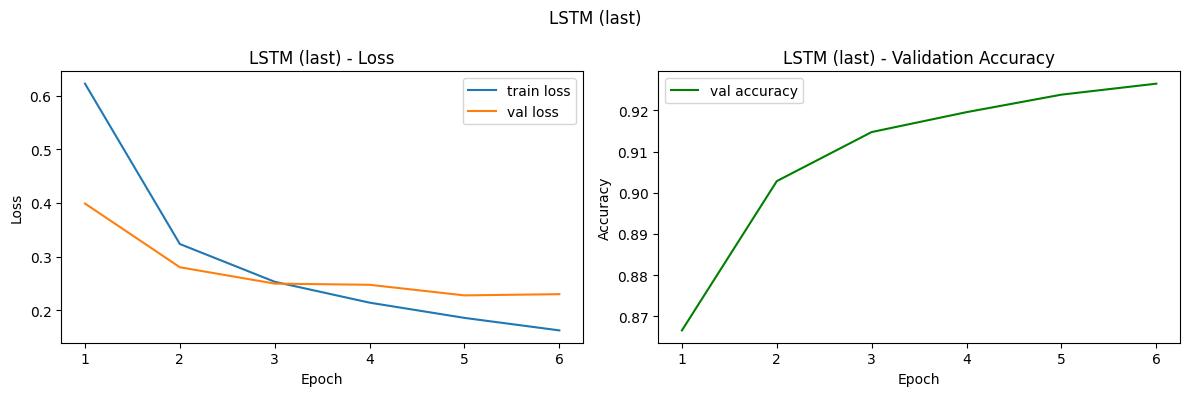


Training: LSTM (mean)
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.5124     0.2961     0.8980    59.2s
    2       0.2867     0.2541     0.9120    58.4s
    3       0.2259     0.2464     0.9203    58.4s
    4       0.1907     0.2309     0.9263    58.2s
    5       0.1633     0.2360     0.9231    57.9s
    6       0.1413     0.2403     0.9263    58.2s

Best val acc: 0.9263 | Total time: 350.4s


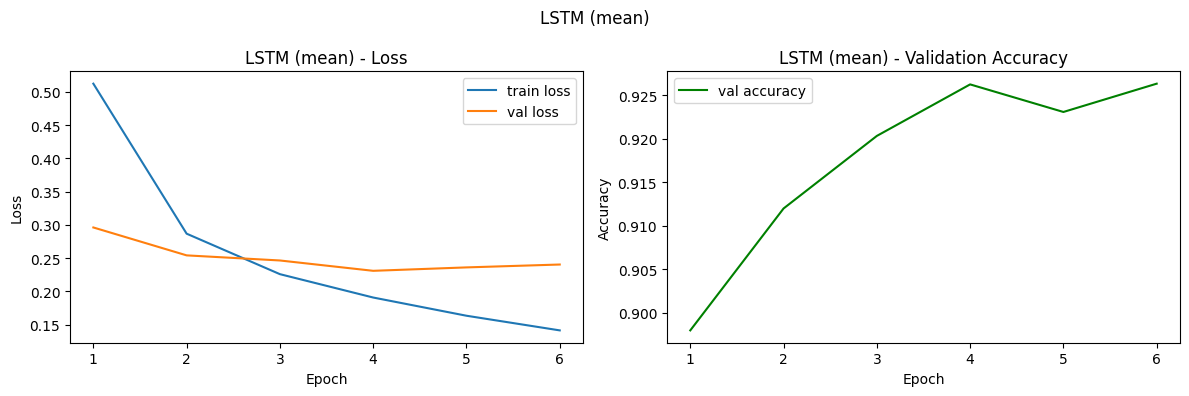


Training: BiLSTM
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.5568     0.3145     0.8935    58.9s
    2       0.2954     0.2657     0.9069    57.8s
    3       0.2321     0.2410     0.9183    56.7s
    4       0.1908     0.2311     0.9223    57.5s
    5       0.1641     0.2312     0.9271    76.0s
    6       0.1405     0.2449     0.9255    58.6s

Best val acc: 0.9271 | Total time: 365.6s


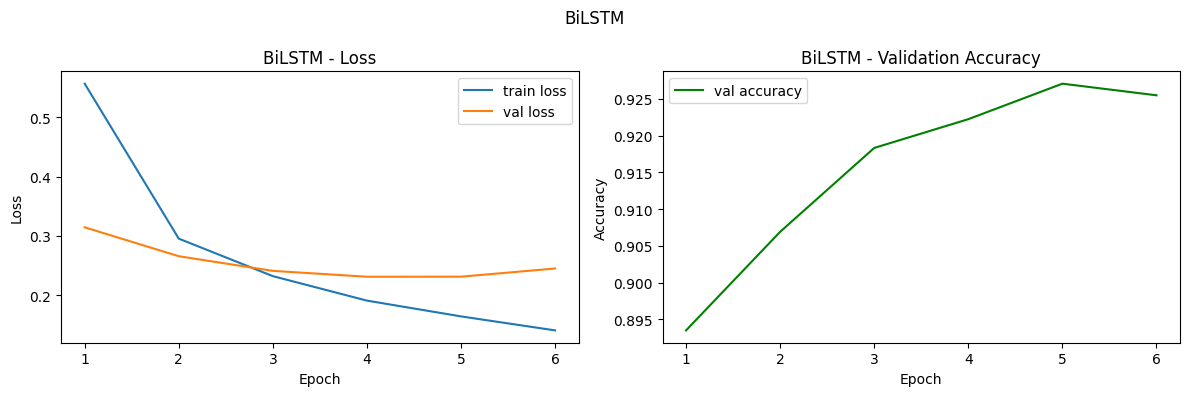


Training: GRU
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.5577     0.3055     0.8955    64.0s
    2       0.2829     0.2432     0.9177    53.8s
    3       0.2263     0.2331     0.9211    53.8s
    4       0.1911     0.2174     0.9277    53.0s
    5       0.1659     0.2188     0.9292    52.6s
    6       0.1465     0.2152     0.9292    56.5s

Best val acc: 0.9292 | Total time: 333.8s


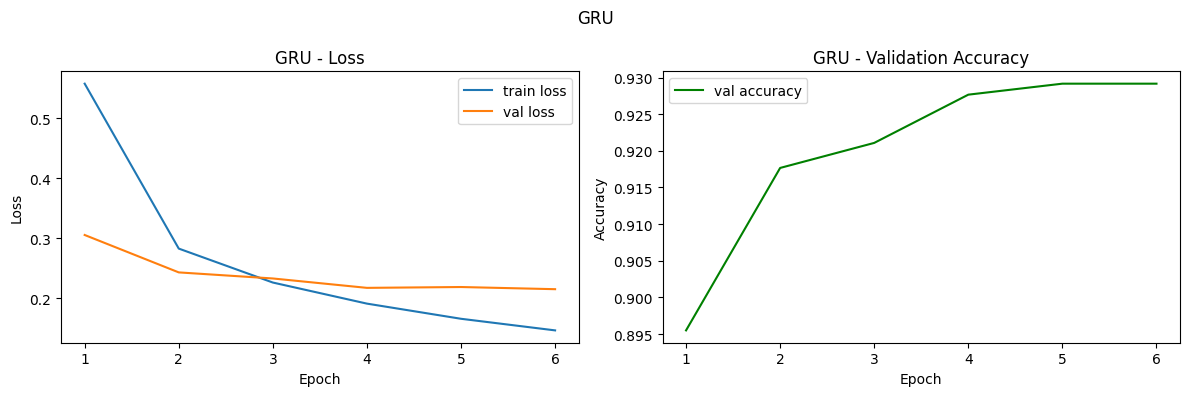

In [7]:
# training function
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(DEVICE)
        lengths   = lengths.to(DEVICE)
        labels    = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss    += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# evaluation function
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths   = lengths.to(DEVICE)
            labels    = labels.to(DEVICE)

            logits = model(input_ids, lengths)
            loss   = criterion(logits, labels)

            total_loss    += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# training runner
def run_training(model, model_name, epochs=6, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history     = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state   = None
    total_start  = time.time()

    print(f"\nTraining: {model_name}")
    print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Time':>8}")
    print("-" * 52)

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, _ = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        epoch_time    = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} "
              f"{val_acc:>10.4f} {epoch_time:>7.1f}s")

    total_time = time.time() - total_start
    print(f"\nBest val acc: {best_val_acc:.4f} | Total time: {total_time:.1f}s")

    # restore best weights
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    return history, total_time

# learning curve plotter
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="train loss")
    ax1.plot(epochs, history["val_loss"],   label="val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} - Loss")
    ax1.legend()

    ax2.plot(epochs, history["val_acc"], label="val accuracy", color="green")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{model_name} - Validation Accuracy")
    ax2.legend()

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_curves.png", dpi=150)
    plt.show()

# train all models
history_lstm_last, time_lstm_last = run_training(lstm_last, "LSTM (last)")
plot_history(history_lstm_last, "LSTM (last)")

history_lstm_mean, time_lstm_mean = run_training(lstm_mean, "LSTM (mean)")
plot_history(history_lstm_mean, "LSTM (mean)")

history_bilstm,    time_bilstm    = run_training(bilstm,    "BiLSTM")
plot_history(history_bilstm,    "BiLSTM")

history_gru,       time_gru       = run_training(gru,       "GRU")
plot_history(history_gru,       "GRU")

Running max-length ablation on LSTM with masked mean pooling...

max_len = 16
  best val acc = 0.8953
  train time   = 259.3s
  truncated    = 99.99%

max_len = 32
  best val acc = 0.9151
  train time   = 298.6s
  truncated    = 91.44%

max_len = 64
  best val acc = 0.9253
  train time   = 332.2s
  truncated    = 10.10%

max_len = 96
  best val acc = 0.9273
  train time   = 356.4s
  truncated    = 2.30%

max_len = 128
  best val acc = 0.9282
  train time   = 366.5s
  truncated    = 0.49%

max_len    best_val_acc    train_time_sec   truncated_pct  
16         0.8953          259.3            99.99          
32         0.9151          298.6            91.44          
64         0.9253          332.2            10.10          
96         0.9273          356.4            2.30           
128        0.9282          366.5            0.49           


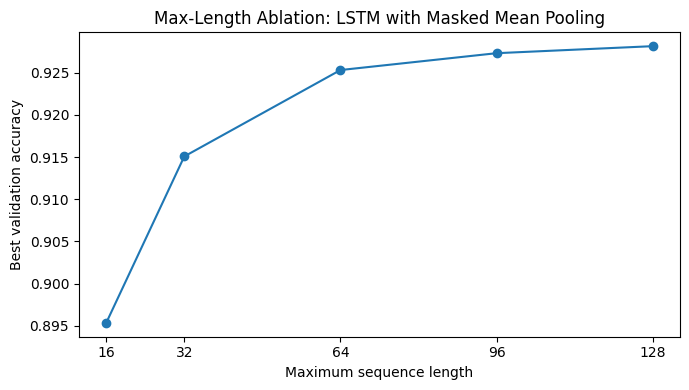

In [8]:
# max-length ablation
ablation_max_lens   = [16, 32, 64, 96, 128]
ablation_epochs     = 6
ablation_lr         = 1e-3
ablation_batch_size = 64
original_max_len    = config.max_len
results             = []

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def run_training_with_loaders(model, train_loader_local, val_loader_local,
                               epochs=6, lr=1e-3):
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr)
    criterion    = nn.CrossEntropyLoss()
    best_val_acc = 0.0
    best_state   = None
    total_start  = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, _ = train_epoch(model, train_loader_local, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader_local, criterion)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.detach().cpu().clone()
                            for k, v in model.state_dict().items()}

    total_time = time.time() - total_start

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    return best_val_acc, total_time

print("Running max-length ablation on LSTM with masked mean pooling...\n")

for max_len in ablation_max_lens:
    print(f"max_len = {max_len}")

    config.max_len = max_len
    set_all_seeds(RANDOM_SEED)

    g_local = torch.Generator()
    g_local.manual_seed(RANDOM_SEED)

    train_encoded_ablation = [encode_text(text, vocab, config) for text in train_texts]
    val_encoded_ablation   = [encode_text(text, vocab, config) for text in val_texts]

    raw_train_lengths = [len(tokenize(text, config)) + int(config.add_sos) +
                         int(config.add_eos) for text in train_texts]
    truncated_count   = sum(1 for l in raw_train_lengths if l > max_len)
    truncated_pct     = 100 * truncated_count / len(raw_train_lengths)

    train_dataset_abl = NewsDataset(train_encoded_ablation, train_labels)
    val_dataset_abl   = NewsDataset(val_encoded_ablation,   val_labels)

    train_loader_abl = DataLoader(train_dataset_abl, batch_size=ablation_batch_size,
                                  shuffle=True,  collate_fn=collate_fn,
                                  worker_init_fn=seed_worker, generator=g_local,
                                  num_workers=0)
    val_loader_abl   = DataLoader(val_dataset_abl,   batch_size=ablation_batch_size,
                                  shuffle=False, collate_fn=collate_fn,
                                  worker_init_fn=seed_worker, generator=g_local,
                                  num_workers=0)

    abl_model = SequenceClassifier(vocab_size=len(vocab), model_type="lstm",
                                   bidirectional=False, pooling="mean").to(DEVICE)

    best_val_acc, total_time = run_training_with_loaders(
        abl_model, train_loader_abl, val_loader_abl,
        epochs=ablation_epochs, lr=ablation_lr)

    results.append({
        "max_len":        max_len,
        "best_val_acc":   best_val_acc,
        "train_time_sec": total_time,
        "truncated_pct":  truncated_pct
    })

    print(f"  best val acc = {best_val_acc:.4f}")
    print(f"  train time   = {total_time:.1f}s")
    print(f"  truncated    = {truncated_pct:.2f}%\n")

config.max_len = original_max_len

print("=" * 64)
print(f"{'max_len':<10} {'best_val_acc':<15} {'train_time_sec':<16} {'truncated_pct':<15}")
print("=" * 64)
for row in results:
    print(f"{row['max_len']:<10} {row['best_val_acc']:<15.4f} "
          f"{row['train_time_sec']:<16.1f} {row['truncated_pct']:<15.2f}")
print("=" * 64)

x = [row["max_len"]      for row in results]
y = [row["best_val_acc"] for row in results]

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker="o")
plt.xlabel("Maximum sequence length")
plt.ylabel("Best validation accuracy")
plt.title("Max-Length Ablation: LSTM with Masked Mean Pooling")
plt.xticks(x)
plt.tight_layout()
plt.savefig("max_length_ablation.png", dpi=150)
plt.show()

In [9]:
# test evaluation
def evaluate_test(model, loader, model_name):
    model.eval()
    total_correct, total_samples = 0, 0
    all_preds, all_labels, all_inputs = [], [], []

    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths   = lengths.to(DEVICE)
            labels    = labels.to(DEVICE)

            logits = model(input_ids, lengths)
            preds  = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_inputs.extend(input_ids.cpu().tolist())

    test_acc = total_correct / total_samples
    print(f"\n{model_name} - Test Accuracy: {test_acc:.4f}")

    return test_acc, all_preds, all_labels, all_inputs

# misclassified examples printer
def show_misclassified(all_preds, all_labels, all_inputs, model_name, n=10):
    misclassified = [
        (all_inputs[i], all_labels[i], all_preds[i])
        for i in range(len(all_preds))
        if all_preds[i] != all_labels[i]
    ]

    print(f"\n{model_name} - Misclassified Examples (showing {n}):")
    print("-" * 60)

    for input_ids, true_label, pred_label in misclassified[:n]:
        text = decode(input_ids, vocab, config)
        print(f"Text:      {text[:120]}...")
        print(f"True:      {label_names[true_label]}")
        print(f"Predicted: {label_names[pred_label]}")
        print("-" * 60)

# per-class breakdown
def class_breakdown(all_preds, all_labels, model_name):
    print(f"\n{model_name} - Per-class Accuracy:")
    for i, name in enumerate(label_names):
        indices = [j for j, l in enumerate(all_labels) if l == i]
        correct = sum(1 for j in indices if all_preds[j] == i)
        print(f"  {name:10s}: {correct}/{len(indices)} "
              f"({100 * correct / len(indices):.1f}%)")

# run test evaluation on all models
models_to_eval = [
    (lstm_last, "LSTM (last)"),
    (lstm_mean, "LSTM (mean)"),
    (bilstm,    "BiLSTM"),
    (gru,       "GRU"),
]

lstm_test_results = {}

for model, model_name in models_to_eval:
    test_acc, all_preds, all_labels, all_inputs = evaluate_test(
        model, test_loader, model_name)
    show_misclassified(all_preds, all_labels, all_inputs, model_name)
    class_breakdown(all_preds, all_labels, model_name)
    lstm_test_results[model_name] = test_acc

# comparison table
histories = {
    "LSTM (last)": history_lstm_last,
    "LSTM (mean)": history_lstm_mean,
    "BiLSTM":      history_bilstm,
    "GRU":         history_gru,
}

print("\n" + "=" * 52)
print(f"{'Model':<20} {'Val Acc (best)':>15} {'Test Acc':>12}")
print("=" * 52)
for model_name, test_acc in lstm_test_results.items():
    best_val = max(histories[model_name]["val_acc"])
    print(f"{model_name:<20} {best_val:>15.4f} {test_acc:>12.4f}")
print("=" * 52)


LSTM (last) - Test Accuracy: 0.9254

LSTM (last) - Misclassified Examples (showing 10):
------------------------------------------------------------
Text:      card fraud unit nets 36 , 000 cards in its first two years , the uk ' s dedicated card fraud unit , has recovered 36 , 0...
True:      Sci/Tech
Predicted: Business
------------------------------------------------------------
Text:      teenage t . rex ' s monster growth tyrannosaurus rex achieved its massive size due to an enormous growth spurt during it...
True:      Sci/Tech
Predicted: Business
------------------------------------------------------------
Text:      venezuela prepares for chavez recall vote supporters and rivals warn of possible fraud ; government says chavez ' s defe...
True:      World
Predicted: Business
------------------------------------------------------------
Text:      promoting a shared vision as michael kept running into people who were getting older and having more vision problems , h...
True:     

In [10]:
# get mean pooled embedding representation of a text
def get_embedding(text, model):
    ids  = encode_text(text, vocab, config)
    ids  = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    mask = (ids != 0).unsqueeze(-1).float()
    with torch.no_grad():
        emb = model.embedding(ids)
        rep = (emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return rep.squeeze(0)

# find most similar training examples to a query text
def find_similar_training(query_text, model, top_k=5, sample=5000):
    query_rep = get_embedding(query_text, model)

    scores = []
    for i in range(sample):
        rep   = get_embedding(train_texts[i], model)
        score = F.cosine_similarity(query_rep.unsqueeze(0),
                                    rep.unsqueeze(0)).item()
        scores.append((score, train_texts[i], train_labels[i]))

    scores.sort(reverse=True)

    print(f"\nQuery: {query_text[:100]}")
    print(f"Top {top_k} similar training examples:")
    print("-" * 60)
    for score, text, label in scores[:top_k]:
        print(f"  [{label_names[label]}] (score: {score:.3f})")
        print(f"  {text[:100]}")
        print()

# misclassified examples to investigate using GRU as best model
misclassified_examples = [
    "dell exits low - end china consumer pc market",
    "yahoo ! ups ante for small businesses",
    "live : olympics day four",
    "card fraud unit nets 36 , 000 cards",
]

print("=" * 60)
print("Embedding Similarity Analysis (GRU)")
print("=" * 60)

for example in misclassified_examples:
    find_similar_training(example, gru, top_k=5, sample=5000)
    print("=" * 60)

Embedding Similarity Analysis (GRU)

Query: dell exits low - end china consumer pc market
Top 5 similar training examples:
------------------------------------------------------------
  [Sci/Tech] (score: 0.422)
  Chip Makers Set Sights on Digital Video Recorders (PC World) PC World - Devices seen as good entry p

  [Sci/Tech] (score: 0.420)
  T-Mobile to battle iPod with music smart phone T-Mobile is pitching its against the likes of Apple a

  [Sci/Tech] (score: 0.412)
  First Look: Voq Cell Phone Needs Work (PC World) PC World - Sierra Wireless promises easy corporate 

  [Sci/Tech] (score: 0.410)
  GeekTech: Picking Your Perfect PCI Express PC (PC World) PC World - Intel-based PCs are shipping now

  [Sci/Tech] (score: 0.407)
  FTC Sues Alleged Spyware Distributors (PC World) PC World - Companies are accused of infecting PCs, 


Query: yahoo ! ups ante for small businesses
Top 5 similar training examples:
------------------------------------------------------------
  [Sci/Tech] (sc

In [11]:
# tokenization comparison: word-level (Task 1) vs DistilBERT subword (Task 2)

# load DistilBERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# example sentence
example_sentence = "Federal Reserve raises interest rates amid inflation concerns."

# word-level tokens from Task 1
word_tokens = tokenize(example_sentence, config)

# DistilBERT subword tokens
bert_tokens = bert_tokenizer.tokenize(example_sentence)
bert_ids    = bert_tokenizer.encode(example_sentence, add_special_tokens=True)

print("Example sentence:")
print(f"  {example_sentence}")
print()
print(f"Word-level tokens ({len(word_tokens)} tokens):")
print(f"  {word_tokens}")
print()
print(f"DistilBERT subword tokens ({len(bert_tokens)} tokens):")
print(f"  {bert_tokens}")
print()
print(f"DistilBERT token IDs (with special tokens [CLS] and [SEP]):")
print(f"  {bert_ids}")
print()
print("Key differences:")
print("  1. Word-level splits on whitespace and punctuation.")
print("     Unknown words become <UNK>.")
print("  2. DistilBERT uses WordPiece subword tokenization.")
print("     Unknown words are split into familiar subword pieces")
print("     e.g. 'inflation' -> ['inflation'], 'hyperinflation' -> ['hyper', '##inflation'].")
print("  3. DistilBERT adds special tokens [CLS] at the start")
print("     and [SEP] at the end automatically.")
print("  4. DistilBERT never produces <UNK> for real English words")
print("     since any word can be decomposed into known subword pieces.")

# attention mask demonstration
encoded = bert_tokenizer(
    example_sentence,
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

print()
print("Attention mask demonstration (max_length=20 for illustration):")
print(f"  input_ids:      {encoded['input_ids'][0].tolist()}")
print(f"  attention_mask: {encoded['attention_mask'][0].tolist()}")
print("  (1 = real token, 0 = padding)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Example sentence:
  Federal Reserve raises interest rates amid inflation concerns.

Word-level tokens (9 tokens):
  ['federal', 'reserve', 'raises', 'interest', 'rates', 'amid', 'inflation', 'concerns', '.']

DistilBERT subword tokens (9 tokens):
  ['federal', 'reserve', 'raises', 'interest', 'rates', 'amid', 'inflation', 'concerns', '.']

DistilBERT token IDs (with special tokens [CLS] and [SEP]):
  [101, 2976, 3914, 13275, 3037, 6165, 13463, 14200, 5936, 1012, 102]

Key differences:
  1. Word-level splits on whitespace and punctuation.
     Unknown words become <UNK>.
  2. DistilBERT uses WordPiece subword tokenization.
     Unknown words are split into familiar subword pieces
     e.g. 'inflation' -> ['inflation'], 'hyperinflation' -> ['hyper', '##inflation'].
  3. DistilBERT adds special tokens [CLS] at the start
     and [SEP] at the end automatically.
  4. DistilBERT never produces <UNK> for real English words
     since any word can be decomposed into known subword pieces.

Atte

In [12]:
# load DistilBERT model
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)
distilbert_model.to(DEVICE)

# parameter count
total_params     = sum(p.numel() for p in distilbert_model.parameters())
trainable_params = sum(p.numel() for p in distilbert_model.parameters()
                       if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# DistilBERT tokenized datasets
def tokenize_fn(example):
    return bert_tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

bert_train_dataset = dataset["train"]
bert_test_dataset  = dataset["test"]

bert_split         = bert_train_dataset.train_test_split(
    test_size=0.10, seed=RANDOM_SEED, shuffle=True)

bert_train_dataset = bert_split["train"]
bert_val_dataset   = bert_split["test"]

bert_train_dataset = bert_train_dataset.map(tokenize_fn, batched=True)
bert_val_dataset   = bert_val_dataset.map(tokenize_fn,   batched=True)
bert_test_dataset  = bert_test_dataset.map(tokenize_fn,  batched=True)

bert_train_dataset.set_format(type="torch",
                               columns=["input_ids", "attention_mask", "label"])
bert_val_dataset.set_format(type="torch",
                             columns=["input_ids", "attention_mask", "label"])
bert_test_dataset.set_format(type="torch",
                              columns=["input_ids", "attention_mask", "label"])

print(f"\nBert train size: {len(bert_train_dataset)}")
print(f"Bert val size:   {len(bert_val_dataset)}")
print(f"Bert test size:  {len(bert_test_dataset)}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,956,548
Trainable parameters: 66,956,548


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]


Bert train size: 108000
Bert val size:   12000
Bert test size:  7600


In [ ]:
# DistilBERT training setup
BERT_BATCH_SIZE = 16
BERT_EPOCHS     = 3
BERT_LR         = 2e-5
BERT_MAX_LEN    = 128
BERT_WD         = 0.05

# dataloaders
bert_train_loader = DataLoader(bert_train_dataset, batch_size=BERT_BATCH_SIZE,
                               shuffle=True,  num_workers=0)
bert_val_loader   = DataLoader(bert_val_dataset,   batch_size=BERT_BATCH_SIZE,
                               shuffle=False, num_workers=0)
bert_test_loader  = DataLoader(bert_test_dataset,  batch_size=BERT_BATCH_SIZE,
                               shuffle=False, num_workers=0)

# optimizer
bert_optimizer = AdamW(distilbert_model.parameters(),
                       lr=BERT_LR, weight_decay=BERT_WD)

# linear warmup scheduler
total_steps   = len(bert_train_loader) * BERT_EPOCHS
warmup_steps  = int(0.1 * total_steps)

bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# training function
def bert_train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# evaluation function
def bert_evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss   = outputs.loss
            logits = outputs.logits

            total_loss    += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# training runner
bert_history    = {"train_loss": [], "val_loss": [], "val_acc": []}
best_bert_acc   = 0.0
best_bert_state = None
total_start     = time.time()

print("Training: DistilBERT")
print(f"  batch_size={BERT_BATCH_SIZE}, epochs={BERT_EPOCHS}, "
      f"lr={BERT_LR}, weight_decay={BERT_WD}")
print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Time':>8}")
print("-" * 52)

for epoch in range(1, BERT_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, _ = bert_train_epoch(
        distilbert_model, bert_train_loader, bert_optimizer, bert_scheduler)
    val_loss, val_acc = bert_evaluate(distilbert_model, bert_val_loader)
    epoch_time    = time.time() - epoch_start

    bert_history["train_loss"].append(train_loss)
    bert_history["val_loss"].append(val_loss)
    bert_history["val_acc"].append(val_acc)

    if val_acc > best_bert_acc:
        best_bert_acc   = val_acc
        best_bert_state = {k: v.cpu().clone()
                           for k, v in distilbert_model.state_dict().items()}

    print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} "
          f"{val_acc:>10.4f} {epoch_time:>7.1f}s")

total_time = time.time() - total_start
print(f"\nBest val acc: {best_bert_acc:.4f} | Total time: {total_time:.1f}s")

# restore best weights
distilbert_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in best_bert_state.items()})

# learning curves
epochs = range(1, BERT_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, bert_history["train_loss"], label="train loss")
ax1.plot(epochs, bert_history["val_loss"],   label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("DistilBERT - Loss")
ax1.legend()

ax2.plot(epochs, bert_history["val_acc"], label="val accuracy", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("DistilBERT - Validation Accuracy")
ax2.legend()

plt.suptitle("DistilBERT")
plt.tight_layout()
plt.savefig("distilbert_curves.png", dpi=150)
plt.show()

bert_total_time = total_time

Training: DistilBERT
  batch_size=16, epochs=3, lr=2e-05, weight_decay=0.05
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.2957     0.1901     0.9415  1304.5s


In [ ]:
# DistilBERT test evaluation
def bert_evaluate_test(model, loader, model_name):
    model.eval()
    total_correct, total_samples = 0, 0
    all_preds, all_labels, all_texts = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            logits  = outputs.logits
            preds   = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_texts.extend([
                bert_tokenizer.decode(ids, skip_special_tokens=True)
                for ids in input_ids.cpu()
            ])

    test_acc = total_correct / total_samples
    print(f"\n{model_name} - Test Accuracy: {test_acc:.4f}")

    return test_acc, all_preds, all_labels, all_texts

# misclassified examples printer for DistilBERT
def bert_show_misclassified(all_preds, all_labels, all_texts, model_name, n=10):
    misclassified = [
        (all_texts[i], all_labels[i], all_preds[i])
        for i in range(len(all_preds))
        if all_preds[i] != all_labels[i]
    ]

    print(f"\n{model_name} - Misclassified Examples (showing {n}):")
    print("-" * 60)

    for text, true_label, pred_label in misclassified[:n]:
        print(f"Text:      {text[:120]}...")
        print(f"True:      {label_names[true_label]}")
        print(f"Predicted: {label_names[pred_label]}")
        print("-" * 60)

# per-class breakdown
def bert_class_breakdown(all_preds, all_labels, model_name):
    print(f"\n{model_name} - Per-class Accuracy:")
    for i, name in enumerate(label_names):
        indices = [j for j, l in enumerate(all_labels) if l == i]
        correct = sum(1 for j in indices if all_preds[j] == i)
        print(f"  {name:10s}: {correct}/{len(indices)} "
              f"({100 * correct / len(indices):.1f}%)")

# run test evaluation
bert_test_acc, bert_all_preds, bert_all_labels, bert_all_texts = bert_evaluate_test(
    distilbert_model, bert_test_loader, "DistilBERT")

bert_show_misclassified(bert_all_preds, bert_all_labels, bert_all_texts, "DistilBERT")
bert_class_breakdown(bert_all_preds, bert_all_labels, "DistilBERT")

In [ ]:
# training dynamics analysis using epoch-level snapshots
# analyses how model behaviour evolved across the 3 training epochs

print("Training Dynamics Analysis - DistilBERT")
print("=" * 60)

# per-epoch val loss and accuracy trajectory
print("\nEpoch-level training trajectory:")
print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10}")
print("-" * 42)
for i, (tl, vl, va) in enumerate(zip(
        bert_history["train_loss"],
        bert_history["val_loss"],
        bert_history["val_acc"]), 1):
    print(f"{i:>5} {tl:>12.4f} {vl:>10.4f} {va:>10.4f}")

# improvement across epochs
val_accs = bert_history["val_acc"]
print(f"\nVal accuracy improvement:")
for i in range(1, len(val_accs)):
    delta = val_accs[i] - val_accs[i-1]
    direction = "up" if delta > 0 else "down"
    print(f"  Epoch {i} -> {i+1}: {delta:+.4f} ({direction})")

print(f"\nBest epoch:    {val_accs.index(max(val_accs)) + 1}")
print(f"Best val acc:  {max(val_accs):.4f}")
print(f"Final val acc: {val_accs[-1]:.4f}")
print(f"Total improvement epoch 1->3: "
      f"{val_accs[-1] - val_accs[0]:+.4f}")

# plot training dynamics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, BERT_EPOCHS + 1)

ax1.plot(epochs, bert_history["train_loss"], marker="o", label="train loss")
ax1.plot(epochs, bert_history["val_loss"],   marker="o", label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("DistilBERT - Loss Dynamics")
ax1.legend()

ax2.plot(epochs, bert_history["val_acc"], marker="o",
         color="green", label="val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("DistilBERT - Accuracy Dynamics")
ax2.legend()

plt.suptitle("DistilBERT Training Dynamics")
plt.tight_layout()
plt.savefig("distilbert_dynamics.png", dpi=150)
plt.show()

# per-class test accuracy analysis
print("\nPer-class test accuracy:")
for i, name in enumerate(label_names):
    indices = [j for j, l in enumerate(bert_all_labels) if l == i]
    correct = sum(1 for j in indices if bert_all_preds[j] == i)
    print(f"  {name:10s}: {correct}/{len(indices)} "
          f"({100 * correct / len(indices):.1f}%)")

In [ ]:
# DistilBERT CLS embedding similarity analysis
# uses the [CLS] token embedding from the final trained model
# to find the most similar training examples to misclassified test examples

def get_cls_embedding(text, model, tokenizer):
    encoded = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=BERT_MAX_LEN,
        return_tensors="pt"
    )
    input_ids      = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = model.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_emb = outputs.last_hidden_state[:, 0, :]

    return cls_emb.squeeze(0).cpu().numpy()

# find most similar training examples using CLS embeddings
def bert_find_similar(query_text, model, tokenizer, top_k=5, sample=5000):
    query_emb = get_cls_embedding(query_text, model, tokenizer)

    scores = []
    for i in range(sample):
        train_text = bert_train_dataset[i]["text"] if "text" in \
                     bert_train_dataset.features else train_texts[i]
        train_emb  = get_cls_embedding(train_text, model, tokenizer)
        score      = float(
            F.cosine_similarity(
                torch.tensor(query_emb).unsqueeze(0),
                torch.tensor(train_emb).unsqueeze(0)
            ).item()
        )
        scores.append((score, train_text, int(bert_train_dataset[i]["label"])))

    scores.sort(reverse=True)

    print(f"\nQuery: {query_text[:100]}")
    print(f"Top {top_k} similar training examples:")
    print("-" * 60)
    for score, text, label in scores[:top_k]:
        print(f"  [{label_names[label]}] (score: {score:.3f})")
        print(f"  {text[:100]}")
        print()

# same misclassified examples used in Task 1 for direct comparison
misclassified_examples = [
    "dell exits low - end china consumer pc market",
    "yahoo ! ups ante for small businesses",
    "live : olympics day four",
    "card fraud unit nets 36 , 000 cards",
]

print("=" * 60)
print("CLS Embedding Similarity Analysis (DistilBERT)")
print("=" * 60)

for example in misclassified_examples:
    bert_find_similar(example, distilbert_model, bert_tokenizer,
                      top_k=5, sample=5000)
    print("=" * 60)

In [ ]:
# combined comparison: Task 1 (LSTM variants) vs Task 2 (DistilBERT)

label_names = ["World", "Sports", "Business", "Sci/Tech"]

# training times from Cell 7 run
time_lstm_last = 317.9
time_lstm_mean = 350.4
time_bilstm    = 365.6
time_gru       = 333.8

# model metadata
all_models = {
    "LSTM (last)": {
        "history":  history_lstm_last,
        "test_acc": lstm_test_results["LSTM (last)"],
        "params":   count_params(lstm_last),
        "time":     time_lstm_last,
    },
    "LSTM (mean)": {
        "history":  history_lstm_mean,
        "test_acc": lstm_test_results["LSTM (mean)"],
        "params":   count_params(lstm_mean),
        "time":     time_lstm_mean,
    },
    "BiLSTM": {
        "history":  history_bilstm,
        "test_acc": lstm_test_results["BiLSTM"],
        "params":   count_params(bilstm),
        "time":     time_bilstm,
    },
    "GRU": {
        "history":  history_gru,
        "test_acc": lstm_test_results["GRU"],
        "params":   count_params(gru),
        "time":     time_gru,
    },
    "DistilBERT": {
        "history":  bert_history,
        "test_acc": bert_test_acc,
        "params":   trainable_params,
        "time":     bert_total_time,
    },
}

# plot 1: validation accuracy curves all models on same axes
plt.figure(figsize=(10, 5))

colors = ["steelblue", "darkorange", "green", "red", "purple"]
styles = ["-", "-", "-", "-", "--"]

for (model_name, data), color, style in zip(all_models.items(), colors, styles):
    epochs = range(1, len(data["history"]["val_acc"]) + 1)
    plt.plot(epochs, data["history"]["val_acc"],
             label=model_name, color=color, linestyle=style, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.tight_layout()
plt.savefig("combined_val_acc.png", dpi=150)
plt.show()

# plot 2: training loss curves all models on same axes
plt.figure(figsize=(10, 5))

for (model_name, data), color, style in zip(all_models.items(), colors, styles):
    epochs = range(1, len(data["history"]["train_loss"]) + 1)
    plt.plot(epochs, data["history"]["train_loss"],
             label=model_name, color=color, linestyle=style, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: All Models")
plt.legend()
plt.tight_layout()
plt.savefig("combined_train_loss.png", dpi=150)
plt.show()

# final comparison table
print("\n" + "=" * 75)
print(f"{'Model':<20} {'Val Acc':>10} {'Test Acc':>10} "
      f"{'Parameters':>15} {'Train Time':>12}")
print("=" * 75)

for model_name, data in all_models.items():
    best_val   = max(data["history"]["val_acc"])
    test_acc   = data["test_acc"]
    params     = data["params"]
    train_time = data["time"]
    print(f"{model_name:<20} {best_val:>10.4f} {test_acc:>10.4f} "
          f"{params:>15,} {train_time:>11.1f}s")

print("=" * 75)